# Float training — YOLOv8n-P3 (ReLU), the topology that is actually built

Trains **the exact network the ZCU102 bitstream was built from** (COCO transfer) on the merged drone set, with full control over the run and live assessment of losses / mAP / per-regime metrics / predictions.

**Gate:** mAP@0.5 > 0.85 on val. Track regimes separately — **close / mid / long**, plus a background false-alarm rate (see `data/drone/manifest.csv`).

**Why `yolov8n_p3_relu.yaml`, not stock yolov8n:** the reference build wires only the stride-8 head, so its bottom-up PAN path (stock layers 16-21) and its P4/P5 head branches are dead logic and were pruned before synthesis. Training the stock 3-head net would produce a graph the proven FINN recipe no longer covers. `scripts/check_v8_topology.py` holds us to it: 41/41 conv shapes identical to the compiled graph. `configs/yolov8n_relu.yaml` (full 3-head) is kept alongside as the what-are-we-giving-up reference.

**Why ReLU, not stock SiLU:** FINN wants ReLU, and pasting ReLU into SiLU-trained weights destroys the model (measured on yolov5n: mAP50 0.963 → 0.078). So the float run trains in ReLU from the start, via `configs/yolov8n_relu.yaml` — Ultralytics' `parse_model` reads its `activation:` key and rebinds `Conv.default_act` before any `Conv` is built.

**Run me with the project venv:** `uv run jupyter lab` (torch 2.4.1+cu121 + `ultralytics`, both project dependencies). For W&B logging, Ultralytics needs it enabled once: `uv run yolo settings wandb=True`.

Cells: setup → config → GPU check → launch (interruptible) → live metrics → per-regime eval → prediction viz.  The metrics/eval/viz cells are re-runnable at any time (during or after training).

## 1. Setup — locate project root

In [1]:
import os, sys
from pathlib import Path

# walk up to the project root (the dir containing `configs/drone.yaml`)
p = Path.cwd()

while not (p / 'configs' / 'drone.yaml').exists() and p != p.parent:
    p = p.parent

PROJ = p
# a failed walk lands on '/', and every later relative path would then resolve
# against the filesystem root instead of failing loudly
assert (PROJ / 'configs' / 'drone.yaml').exists(), f'project root not found above {Path.cwd()}'
os.chdir(PROJ)                      # run everything relative to project root

import ultralytics
from ultralytics import YOLO
from ultralytics.utils import DEFAULT_CFG_DICT   # Ultralytics' own hyp defaults

print('project root :', PROJ)
print('python       :', sys.executable)
print('ultralytics  :', ultralytics.__version__)

project root : /home/alex/Repos/drone-detect
python       : /home/alex/Repos/drone-detect/.venv/bin/python
ultralytics  : 8.3.253


## 2. Config — all knobs
Edit freely, then run the launch cell. `name` gets auto-suffixed by Ultralytics if it already exists (v8n_relu, v8n_relu2, ...), unless `exist_ok=True`.

In [2]:
NBS = 64          # Ultralytics' nominal batch size (`args.nbs`) — all its optimizer
                  # math is pinned to this. batch = NBS * BATCH_MULT.
BATCH_MULT = 3    # 1 = stock regime. >1 multiplies the batch on its value and compensates lr0 /
                  # weight_decay so the training regime is preserved (see derive_hyp).

CFG = dict(
    name    = 'v8n_p3_relu6',
    # run train or not
    train   = True,
    data    = 'configs/drone.yaml',                     # dataset yaml (abs paths inside)
    weights = 'weights/yolov8n.pt',                     # COCO-pretrained start ('' = from scratch)
    # model yaml. None = the checkpoint's own architecture (stock 3-head SiLU).
    #   configs/yolov8n_p3_relu6.yaml -> the COMPILED topology: backbone + top-down
    #     FPN + a single stride-8 head. 1.61M params. This is the one to train.
    #     ReLU6, not ReLU: the reference quantizes every activation to a single
    #     common range [0, 6] (build_notes 10.9), and a plain-ReLU net does not
    #     fit in it — ours peaks at 210 and puts 10-13%% of early-layer values
    #     above 6. Train into the range instead of clipping to it later.
    #   configs/yolov8n_p3_relu.yaml  -> same topology, plain ReLU. Trained; kept
    #     as the measurement of what the ReLU6 clamp costs.
    #   configs/yolov8n_relu.yaml    -> full 3-head yolov8n, ReLU. 3.01M params.
    #     Not buildable with the current recipe; useful only to measure the cost
    #     of dropping P4/P5.
    # COCO weights transfer into either (activations carry no parameters, and the
    # backbone/FPN layers are stock); the head is reinitialised for nc=1.
    model_cfg = 'configs/yolov8n_p3_relu6.yaml',
    # per-experiment hyp / augmentation overrides, applied on top of Ultralytics'
    # defaults AND on top of the batch-scaled lr0 / weight_decay below.
    # Keys must exist in ultralytics/cfg/default.yaml.
    hyp_overrides = {
        'mosaic': 0.5,
        },
    # --- schedule ---
    epochs   = 100,
    patience = 30,        # early-stop if no val improvement for N epochs
    # --- batch / resolution ---
    # The built bitstream runs 192x320. Ultralytics trains SQUARE only, so 320
    # is the matching choice — and the net is fully convolutional, so it can be
    # exported at 320x320 or 192x320 afterwards without retraining. Going above
    # 320 costs resources quadratically and BRAM is already at 79.6% (§10.7).
    img   = 320,
    batch = NBS * BATCH_MULT,
    batch_mult = BATCH_MULT,
    # --- optimizer ---
    # PIN IT. Ultralytics' default is 'auto', which DISCARDS lr0/momentum and
    # picks AdamW below 10k iterations — see the note in derive_hyp.
    optimizer = 'SGD',
    # --- runtime ---
    device  = 0,          # GPU index, or 'cpu'
    workers = 12,
    cache   = None,       # None | 'ram' | 'disk'  (ram is fastest if RAM allows)
    seed    = 0,
    # --- logging ---
    # Ultralytics ships W&B logging OFF by default and says nothing about it.
    # True makes the GPU-check cell turn it on in ~/.config/Ultralytics/settings.json.
    wandb = True,
    # Ultralytics reuses `project` as the W&B PROJECT NAME
    # (wb.init(project=str(args.project).replace('/', '-'))), and `project`
    # must be an absolute path for the output dir to land right — so the two
    # requirements collide in one field. The launch cell breaks the tie by
    # calling wandb.init() itself first; Ultralytics' callback is guarded by
    # `if not wb.run:` and adopts the existing run.
    wandb_project = 'YOLOv8',
    # --- output ---
    # MUST be ABSOLUTE. get_save_dir treats any project with more than one path
    # component as a nested NAME and re-roots it under RUNS_DIR/<task>, so a
    # relative 'runs/train' silently lands in runs/detect/runs/train/. An
    # absolute path wins the join and is used verbatim.
    project  = str(PROJ / 'runs' / 'train'),
    exist_ok = False,     # True = overwrite `name` instead of suffixing
    resume   = False,     # True = resume last interrupted run (ignores most knobs above)
)

CFG

{'name': 'v8n_p3_relu6',
 'train': True,
 'data': 'configs/drone.yaml',
 'weights': 'weights/yolov8n.pt',
 'model_cfg': 'configs/yolov8n_p3_relu6.yaml',
 'hyp_overrides': {'mosaic': 0.5},
 'epochs': 100,
 'patience': 30,
 'img': 320,
 'batch': 192,
 'batch_mult': 3,
 'optimizer': 'SGD',
 'device': 0,
 'workers': 12,
 'cache': None,
 'seed': 0,
 'wandb': True,
 'project': '/home/alex/Repos/drone-detect/runs/train',
 'exist_ok': False,
 'resume': False}

## 3. Environment / GPU check

In [3]:
import torch

print('torch        :', torch.__version__)
print('cuda avail   :', torch.cuda.is_available())

if torch.cuda.is_available():
    print('device       :', torch.cuda.get_device_name(0))
    free, total = torch.cuda.mem_get_info()
    print(f'gpu mem      : {free/1e9:.1f} GB free / {total/1e9:.1f} GB total')

from ultralytics.utils import SETTINGS
if CFG.get('wandb') and not SETTINGS.get('wandb'):
    SETTINGS.update({'wandb': True})     # persists to ~/.config/Ultralytics/settings.json
    print('wandb       : was OFF -> enabled (restart the kernel if a run is already live)')
else:
    print('wandb       :', 'on' if SETTINGS.get('wandb') else 'off')

assert Path(CFG['weights']).exists(), f"missing weights: {CFG['weights']}"
assert Path(CFG['data']).exists(),    f"missing data yaml: {CFG['data']}"

# The ReLU swap is silent if the yaml key is misspelled, and a SiLU model that
# trains fine is exactly what we must not hand to FINN — so assert it here.
if CFG.get('model_cfg'):
    import torch.nn as nn
    _probe = YOLO(CFG['model_cfg']).model
    _acts = {type(m).__name__ for m in _probe.modules() if isinstance(m, (nn.SiLU, nn.ReLU, nn.ReLU6))}
    print('activations  :', _acts or '{}')
    assert _acts <= {'ReLU', 'ReLU6'} and _acts, f'expected ReLU/ReLU6, got {_acts} — check `activation:` in {CFG["model_cfg"]}'
    assert 'SiLU' not in _acts
    del _probe

torch        : 2.4.1+cu121
cuda avail   : True
device       : NVIDIA GeForce RTX 4090
gpu mem      : 23.5 GB free / 25.3 GB total
wandb       : on
activations  : {'ReLU6'}


## 4. Launch training (interruptible)
Runs Ultralytics **in-process** (unlike the YOLOv5 version, which shelled out to `train.py`) — the ReLU rebind and the W&B id capture both need Python-level hooks. **To stop early:** interrupt the kernel (■ / `Kernel > Interrupt`); Ultralytics has already written `last.pt`/`best.pt` for every finished epoch. Re-run with `resume=True` to continue.

In [4]:
def derive_hyp(cfg):
    """Training-regime kwargs for `.train()`: batch-scaled lr0/weight_decay plus
    any cfg['hyp_overrides']. Returns a dict; empty when there's nothing to change.

    batch scaling — Ultralytics pins its optimizer math to nbs=64
    (BaseTrainer._setup_train), exactly like YOLOv5:
        accumulate    = max(round(64 / batch), 1)      -> 1 for batch >= 64
        weight_decay *= batch * accumulate / 64        -> i.e. multiplied by m
    ...but it never touches lr0. So for batch = 64*m we pre-adjust:
        lr0          *= m   linear scaling rule — m-fold fewer optimizer steps
                            per epoch, so each must be m-fold larger.
        weight_decay /= m   cancels Ultralytics' own *= m, so wd ends at its
                            ORIGINAL value once lr0 is scaled.
    Warmup needs no adjustment: it is counted in epochs (warmup_epochs * nb) and
    nb already shrinks by m.

    GOTCHA — optimizer='auto' is the Ultralytics DEFAULT and it *discards* lr0
    and momentum, substituting AdamW at lr = 0.002*5/(4+nc) whenever the run is
    under 10k iterations (build_optimizer). That would silently void everything
    above, which is why CFG pins optimizer='SGD' — the YOLOv5 baseline's choice,
    so the two runs stay comparable.

    overrides — cfg['hyp_overrides'] is applied last. Keys must already exist in
    Ultralytics' default cfg; a typo'd key raises rather than silently no-op'ing.
    """
    m = cfg.get('batch_mult', 1)
    overrides = dict(cfg.get('hyp_overrides') or {})
    out, notes = {}, []

    if m > 1:
        lr0_base, wd_base = DEFAULT_CFG_DICT['lr0'], DEFAULT_CFG_DICT['weight_decay']
        out['lr0'] = lr0_base * m
        out['weight_decay'] = wd_base / m
        notes.append(f"batch_mult={m}: batch={cfg['batch']}  lr0 {lr0_base:g} -> {out['lr0']:g}  "
                     f"weight_decay {wd_base:g} -> {out['weight_decay']:g} "
                     f"(trainer scales it back to {out['weight_decay'] * m:g})")

    for k, v in overrides.items():
        if k not in DEFAULT_CFG_DICT:
            raise KeyError(f'hyp_overrides key {k!r} is not an Ultralytics cfg key — '
                           f'it would be rejected. Check the spelling.')
        notes.append(f'override {k}: {DEFAULT_CFG_DICT[k]} -> {v}')
        out[k] = v

    if notes:
        print('\n'.join(notes))
    return out


def build_model(cfg):
    """Same semantics as YOLOv5's `--cfg X --weights Y`: build the graph from the
    yaml (so `activation: nn.ReLU()` takes effect), then transfer whatever weights
    still match. Without a model_cfg, the checkpoint's own graph is used (SiLU)."""
    if cfg.get('resume'):
        return None                                    # handled in run_training
    if cfg.get('model_cfg'):
        model = YOLO(cfg['model_cfg'])
        if cfg.get('weights'):
            model.load(cfg['weights'])
        return model
    return YOLO(cfg['weights'])


def _grab_wandb_id(trainer):
    """Persist the W&B run id beside the checkpoints so the eval cells can attach
    their metrics to THIS run. It has to be taken while the run is live —
    Ultralytics' own callback calls wandb.run.finish() when training ends."""
    try:
        import wandb as wb
        if wb.run is not None:
            Path(trainer.save_dir).mkdir(parents=True, exist_ok=True)
            (Path(trainer.save_dir) / 'wandb_run_id.txt').write_text(wb.run.id + '\n')
            print(f'W&B run id {wb.run.id} -> {trainer.save_dir}/wandb_run_id.txt')
    except Exception as e:                             # never let logging kill a run
        print('wandb id capture skipped:', e)


def run_training(cfg):
    if cfg.get('resume'):
        last = Path(cfg['project']) / cfg['name'] / 'weights' / 'last.pt'
        assert last.exists(), f'nothing to resume: {last} missing'
        model = YOLO(str(last))
        kw = dict(resume=True)
    else:
        model = build_model(cfg)
        kw = dict(
            data=cfg['data'], epochs=cfg['epochs'], patience=cfg['patience'],
            imgsz=cfg['img'], batch=cfg['batch'], optimizer=cfg['optimizer'],
            device=cfg['device'], workers=cfg['workers'], seed=cfg['seed'],
            project=cfg['project'], name=cfg['name'], exist_ok=cfg['exist_ok'],
        )
        if cfg.get('cache'):
            kw['cache'] = cfg['cache']
        kw.update(derive_hyp(cfg))

    if cfg.get('wandb'):
        import wandb as wb
        if wb.run is not None:
            wb.finish()                       # a stale run would be adopted instead
        wb.init(project=cfg['wandb_project'], name=cfg['name'],
                config={k: v for k, v in cfg.items() if k != 'hyp_overrides'})

    model.add_callback('on_train_start', _grab_wandb_id)
    print('training kwargs:', kw, '\n' + '-' * 80)

    try:
        model.train(**kw)
    except KeyboardInterrupt:
        print('\n[interrupted] training stopped — best.pt/last.pt kept in the run dir')

    return model


if CFG["train"]:
    trained = run_training(CFG)
    # authoritative — do not re-derive it by globbing, Ultralytics may have
    # suffixed the name (v8n_p3_relu2, ...) or re-rooted the project
    LAST_RUN_DIR = Path(trained.trainer.save_dir)
    print('\nrun dir:', LAST_RUN_DIR)
else:
    print("Train flag is False, train skipped")

Transferred 210/239 items from pretrained weights
batch_mult=3: batch=192  lr0 0.01 -> 0.03  weight_decay 0.0005 -> 0.000166667 (trainer scales it back to 0.0005)
override mosaic: 1.0 -> 0.5
training kwargs: {'data': 'configs/drone.yaml', 'epochs': 100, 'patience': 30, 'imgsz': 320, 'batch': 192, 'optimizer': 'SGD', 'device': 0, 'workers': 12, 'seed': 0, 'project': '/home/alex/Repos/drone-detect/runs/train', 'name': 'v8n_p3_relu6', 'exist_ok': False, 'lr0': 0.03, 'weight_decay': 0.00016666666666666666, 'mosaic': 0.5} 
--------------------------------------------------------------------------------
New https://pypi.org/project/ultralytics/8.4.118 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.253 🚀 Python-3.11.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=192, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, c

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/alex/.netrc.
wandb: Currently logged in as: beatwad to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Overriding model.yaml nc=80 with nc=1
activation: nn.ReLU6()

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1

libpng warning: iCCP: known incorrect sRGB profile


      1/100      5.09G      3.643      2.857      3.963        264        320: 47% ━━━━━╸────── 73/155 6.8it/s 20.8s<12.1s

...

libpng warning: iCCP: known incorrect sRGB profile


    100/100      6.57G       1.15      0.482      1.234         38        320: 100% ━━━━━━━━━━━━ 155/155 6.8it/s 22.9s0.3s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.9it/s 10.2s.6s
                   all       7294       6371      0.942      0.886      0.938      0.609

100 epochs completed in 0.979 hours.
Optimizer stripped from /home/alex/Repos/drone-detect/runs/train/v8n_p3_relu62/weights/last.pt, 3.4MB
Optimizer stripped from /home/alex/Repos/drone-detect/runs/train/v8n_p3_relu62/weights/best.pt, 3.4MB

Validating /home/alex/Repos/drone-detect/runs/train/v8n_p3_relu62/weights/best.pt...
Ultralytics 8.3.253 🚀 Python-3.11.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
YOLOv8n_p3_relu6 summary (fused): 48 layers, 1,606,993 parameters, 0 gradients, 6.0 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 1.4it/s 13.4s0.7s
        

wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 100 that is less than the current step 101. Steps must be monotonically increasing, so this data will be ignored. See ht

lr/pg0,█▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
lr/pg1,▃▆█████▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
lr/pg2,▆████▇▇▇▇▇▆▆▆▆▅▅▅▅▅▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
metrics/mAP50(B),▁▂▅▆▆▇▆▆▇▇▇▇██▇█████████████████████████
metrics/mAP50-95(B),▁▂▄▃▄▆▆▆▆▇▆▆▇▇▇▇▇▇▇▇▇▇▇█████████████████
metrics/precision(B),▂▂▁▃▅▆▇▇▇▇▅▇▇▇▇▇▇██▇▇███████████████████
metrics/recall(B),▅▃▃▄▅▁▅▆▆▇▆▆▇▆▆▆▇▇▇▇▇▇▇█▇███████████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...



run dir: /home/alex/Repos/drone-detect/runs/train/v8n_p3_relu62


## 5. Live metrics — loss & mAP curves + gate check
Reads `results.csv` (Ultralytics appends a row per epoch). **Re-run this cell any time** while training to refresh the curves. It auto-picks the newest run dir matching `CFG['name']`; override `RUN_DIR` manually if needed.

In [5]:
import pandas as pd, matplotlib.pyplot as plt

# Ultralytics 'fitness' — the exact score that selects best.pt & drives early-stop
# (utils/metrics.py: Metric.fitness). NOTE it changed: YOLOv5 and older Ultralytics
# used 0.1*mAP@.5 + 0.9*mAP@.5:.95; 8.3.253 weights mAP@.5:.95 alone. Re-check
# `Metric.fitness` if you bump the version.
W_FITNESS = dict(precision=0.0, recall=0.0, mAP50=0.0, mAP50_95=1.0)


def latest_run(project, name):
    runs = sorted(Path(project).glob(name + '*'), key=lambda d: d.stat().st_mtime)
    return runs[-1] if runs else None

# the training cell records the exact dir; the glob is only for a fresh kernel
RUN_DIR = globals().get('LAST_RUN_DIR') or latest_run(CFG['project'], CFG['name'])

if CFG["train"]:   # or: RUN_DIR = Path('runs/train/v8n_relu')
    assert RUN_DIR and (RUN_DIR / 'results.csv').exists(), 'no results.csv yet — let training run an epoch'
    print('run dir:', RUN_DIR)

    df = pd.read_csv(RUN_DIR / 'results.csv')
    df.columns = [c.strip() for c in df.columns]

    df['fitness'] = (W_FITNESS['precision'] * df['metrics/precision(B)']
                     + W_FITNESS['recall'] * df['metrics/recall(B)']
                     + W_FITNESS['mAP50'] * df['metrics/mAP50(B)']
                     + W_FITNESS['mAP50_95'] * df['metrics/mAP50-95(B)'])
    best = df.loc[df['fitness'].idxmax()]   # == the epoch Ultralytics saved as best.pt

    fig, ax = plt.subplots(1, 2, figsize=(15, 5))
    # YOLOv8 is anchor-free with a DFL head: box + cls + dfl, and NO objectness loss.
    for c, lbl in [('train/box_loss','train box'), ('train/cls_loss','train cls'),
                   ('train/dfl_loss','train dfl'), ('val/box_loss','val box'),
                   ('val/cls_loss','val cls'),     ('val/dfl_loss','val dfl')]:
        ax[0].plot(df['epoch'], df[c], label=lbl)

    ax[0].set_title('losses')
    ax[0].set_xlabel('epoch')
    ax[0].legend()
    ax[0].grid(alpha=.3)

    for c, lbl in [('metrics/precision(B)','P'), ('metrics/recall(B)','R'),
                   ('metrics/mAP50(B)','mAP@.5'), ('metrics/mAP50-95(B)','mAP@.5:.95'),
                   ('fitness','fitness')]:
        ax[1].plot(df['epoch'], df[c], label=lbl)

    ax[1].axhline(0.85, ls='--', c='r', alpha=.6, label='gate 0.85')
    ax[1].axvline(best['epoch'], ls=':', c='k', alpha=.6, label=f"best (ep {int(best['epoch'])})")
    ax[1].set_title('val metrics')
    ax[1].set_xlabel('epoch')
    ax[1].legend()
    ax[1].grid(alpha=.3)

    plt.tight_layout()
    plt.show()

    # best epoch ranked by fitness -> matches the checkpoint Ultralytics wrote to best.pt
    print(f"best epoch {int(best['epoch'])} (fitness = {best['fitness']:.4f}): "
          f"mAP@.5={best['metrics/mAP50(B)']:.4f} mAP@.5:.95={best['metrics/mAP50-95(B)']:.4f} "
          f"P={best['metrics/precision(B)']:.3f} R={best['metrics/recall(B)']:.3f}")
    print('GATE mAP@0.5 > 0.85:', 'PASS ✅' if best['metrics/mAP50(B)'] > 0.85 else 'FAIL ❌')

run dir: /home/alex/Repos/drone-detect/runs/train/v8n_p3_relu62


<Figure size 1500x500 with 2 Axes>

best epoch 100 (fitness = 0.6094): mAP@.5=0.9385 mAP@.5:.95=0.6094 P=0.942 R=0.886
GATE mAP@0.5 > 0.85: PASS ✅


## 6. Per-regime evaluation (close / mid / long + background)
Aggregate mAP mixes regimes with very different difficulty. This evaluates `best.pt` on each regime's val subset separately — **close-range is our real target metric.** Runs after training finishes (needs `best.pt`).

`regime` is derived per-image from the largest GT box (`close` ≥10% of frame, `long` <1%, `mid` between) by `scripts/merge_dataset.py`, which also writes the `configs/val_<regime>.txt` subsets **from the same run that decides the split** — so they cannot drift out of sync with it. `empty` images have no GT box, so mAP is undefined there; they are scored as a false-alarm rate instead.

In [ ]:
import wandb

WANDB_LOG = True          # attach eval metrics to the run's W&B entry

best_w = RUN_DIR / 'weights' / 'best.pt'
assert best_w.exists(), f'no best.pt at {best_w} — finish (or interrupt) training first'

def wandb_attach(run_dir, project=None):
    """Resume the training run so eval metrics land ON it rather than beside it.

    The id comes from wandb_run_id.txt, written by the on_train_start callback in
    the launch cell. If it's absent (W&B disabled in Ultralytics settings, or an
    older run dir) we fall back to a separate '<run>-eval' run rather than
    guessing — several run dirs can share the same name stem.
    """
    project = project or CFG['wandb_project']
    idf = run_dir / 'wandb_run_id.txt'
    if idf.exists():
        return wandb.init(project=project, id=idf.read_text().strip(),
                          resume='must', reinit=True)
    print(f'no {idf.name} in {run_dir} — logging to a separate "{run_dir.name}-eval" run')
    return wandb.init(project=project, name=f'{run_dir.name}-eval', reinit=True)

# regimes that carry ground-truth boxes. `empty` has none, so mAP is undefined
# there and it is scored separately below.
BOXED = ('close', 'mid', 'long')

eval_model = YOLO(str(best_w))

rows = {}
for regime in BOXED:
    cfg = Path(f'configs/drone_val_{regime}.yaml')
    if not cfg.exists():
        print(f'skip {regime}: {cfg} missing — re-run scripts/merge_dataset.py')
        continue
    # Ultralytics caches scanned labels at data/drone/val/labels.cache, which is
    # SHARED by every regime subset — and is the SAME path the vendored yolov5
    # uses, in an incompatible format. Both sides validate a version + file-list
    # hash and rescan on mismatch, so this is self-healing; it just costs a
    # rescan every time you alternate regimes, or yolov5 and yolov8 runs.
    res = eval_model.val(data=str(cfg), imgsz=CFG['img'], batch=CFG['batch'],
                         split='val', device=CFG['device'], workers=CFG['workers'],
                         verbose=False, plots=False,
                         project=str(PROJ / 'runs' / 'val'),
                         name=f'{RUN_DIR.name}_{regime}', exist_ok=True)
    rows[regime] = dict(P=res.box.mp, R=res.box.mr, mAP50=res.box.map50, mAP50_95=res.box.map)

tbl = pd.DataFrame(rows).T
print(tbl.to_string(float_format=lambda x: f'{x:.4f}'))
print('\nclose-range gate mAP@0.5 > 0.85:',
      'PASS ✅' if rows.get('close', {}).get('mAP50', 0) > 0.85 else 'FAIL ❌')

if CFG["train"] and WANDB_LOG and rows:
    wb = wandb_attach(RUN_DIR)
    # scalars -> run summary, so they become sortable/comparable columns in the
    # W&B runs table; the table itself is logged for the full breakdown.
    wb.summary.update({f'eval/{r}/{k}': float(v) for r, d in rows.items() for k, v in d.items()})
    wb.log({'eval/per_regime': wandb.Table(
        dataframe=tbl.reset_index().rename(columns={'index': 'regime'}))})
    print('logged per-regime metrics ->', wb.url)
    wb.finish()

Ultralytics 8.3.253 🚀 Python-3.11.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
YOLOv8n_p3_relu6 summary (fused): 48 layers, 1,606,993 parameters, 0 gradients, 6.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1899.8±638.7 MB/s, size: 29.1 KB)
val: Scanning /home/alex/Repos/drone-detect/data/drone/val/labels... 1713 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1713/1713 3.1Kit/s 0.6s0.1s
val: New cache created: /home/alex/Repos/drone-detect/data/drone/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.7it/s 5.2s0.3ss
                   all       1713       1748      0.974      0.961      0.985      0.713
Speed: 0.2ms preprocess, 0.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Ultralytics 8.3.253 🚀 Python-3.11.12 torch-2.4.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4090, 24081MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2374.8±900.8 MB/s, size: 40.5 KB)
val: Sca

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


UsageError: You provided an invalid value for the `resume` argument. The value 'must' is not a valid option for resuming the run (j49tuxej) that has not been initialized. Please check your inputs and try again with a valid run ID. If you are trying to start a new run, please omit the `resume` argument or use `resume='allow'`.

## 6b. Localization quality — mean IoU
Mean IoU of matched **true-positive** detections vs ground truth (greedy one-to-one matching, `conf ≥ CONF_THR`, `IoU ≥ 0.5`) — a box-tightness metric, distinct from mAP and directly relevant to **aim precision**. Reported overall + per regime. Needs `best.pt`; reuses `eval_model` from cell 6.

In [ ]:
import numpy as np, cv2

CONF_THR = 0.5    # detection confidence threshold
IOU_TP   = 0.50   # IoU >= this counts as a matched true positive
IOU_NMS  = 0.45   # NMS IoU threshold used at inference

def _iou_matrix(pred, gt):
    if len(pred) == 0 or len(gt) == 0:
        return np.zeros((len(pred), len(gt)))
    ap = (pred[:, 2] - pred[:, 0]) * (pred[:, 3] - pred[:, 1])
    ag = (gt[:, 2] - gt[:, 0]) * (gt[:, 3] - gt[:, 1])
    lt = np.maximum(pred[:, None, :2], gt[None, :, :2])
    rb = np.minimum(pred[:, None, 2:], gt[None, :, 2:])
    wh = np.clip(rb - lt, 0, None)
    inter = wh[..., 0] * wh[..., 1]
    return inter / (ap[:, None] + ag[None, :] - inter + 1e-9)

def _load_gt(img_path, w, h):
    lp = img_path.replace('/images/', '/labels/').rsplit('.', 1)[0] + '.txt'
    boxes = []
    if os.path.exists(lp):
        for line in open(lp):
            s = line.split()
            if len(s) >= 5:
                cx, cy, bw, bh = map(float, s[1:5])
                boxes.append([(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h])
    return np.array(boxes, float).reshape(-1, 4)

def _predict(img_path, conf=None):
    """[x1,y1,x2,y2,conf,cls] in ORIGINAL image pixels. Ultralytics has no
    persistent model.conf/model.iou like the YOLOv5 hub wrapper — thresholds are
    per-call arguments, so they are passed explicitly everywhere below."""
    # project/name pinned: get_save_dir mkdir's a directory per predictor even
    # with save=False, so without this every threshold change leaves another
    # empty runs/detect/predictN behind
    r = eval_model.predict(img_path, imgsz=CFG['img'], conf=CONF_THR if conf is None else conf,
                           iou=IOU_NMS, device=CFG['device'], verbose=False,
                           project=str(PROJ / 'runs' / 'predict'), name=RUN_DIR.name,
                           exist_ok=True)[0]
    return r.boxes.data.cpu().numpy()

def collect_ious(img_paths):
    """IoU of each greedy one-to-one matched (pred, gt) pair with IoU >= IOU_TP."""
    ious = []
    for ip in img_paths:
        im = cv2.imread(ip)
        if im is None:
            continue
        h, w = im.shape[:2]
        gt = _load_gt(ip, w, h)
        pred = _predict(ip)[:, :4]
        M = _iou_matrix(pred, gt)
        cand = sorted((M[i, j], i, j) for i in range(M.shape[0]) for j in range(M.shape[1])
                      if M[i, j] >= IOU_TP)
        used_p, used_g = set(), set()
        for v, i, j in reversed(cand):                  # highest IoU first
            if i in used_p or j in used_g:
                continue
            used_p.add(i)
            used_g.add(j)
            ious.append(v)
    return ious

# BOXED (close/mid/long) comes from the per-regime eval cell — `empty` is skipped
# here since it has no GT boxes to match against.
iou_by_regime = {r: collect_ious(Path(f'configs/val_{r}.txt').read_text().split())
                 for r in BOXED if Path(f'configs/val_{r}.txt').exists()}
iou_by_regime['overall'] = [v for vals in iou_by_regime.values() for v in vals]

iou_tbl = pd.DataFrame({
    r: dict(mean_IoU=(np.mean(v) if v else float('nan')), n_TP=len(v))
    for r, v in iou_by_regime.items()
}).T
print(f'localization quality — mean IoU of matched TPs (conf>={CONF_THR}, IoU>={IOU_TP})')
print(iou_tbl.to_string(float_format=lambda x: f'{x:.4f}'))

if CFG["train"] and WANDB_LOG and any(iou_by_regime.values()):
    wb = wandb_attach(RUN_DIR)          # same run as the per-regime cell
    wb.summary.update({f'eval/{r}/mean_IoU': float(np.mean(v))
                       for r, v in iou_by_regime.items() if v})
    wb.summary.update({f'eval/{r}/n_TP': len(v) for r, v in iou_by_regime.items()})
    wb.summary.update({'eval/iou_conf_thr': CONF_THR, 'eval/iou_tp_thr': IOU_TP})
    wb.log({'eval/mean_iou': wandb.Table(
        dataframe=iou_tbl.reset_index().rename(columns={'index': 'regime'}))})
    print('logged mean-IoU metrics ->', wb.url)
    wb.finish()

localization quality — mean IoU of matched TPs (conf>=0.5, IoU>=0.5)
         mean_IoU      n_TP
close      0.8453 1666.0000
mid        0.8389 1893.0000
long       0.7908 1714.0000
overall    0.8252 5273.0000


logged mean-IoU metrics -> https://wandb.ai/beatwad/YOLOv8/runs/98z0je9m


best/epoch,98
best/mAP50,0.94059
best/mAP50-95,0.60939
best/precision,0.93719
best/recall,0.89044
eval/close/P,0.97196
eval/close/R,0.96854
eval/close/mAP50,0.9878
eval/close/mAP50_95,0.71752
eval/close/mean_IoU,0.84525
+38,...


## 6b-2. Aim precision — mean center error
Distance between predicted and ground-truth **box centers** for matched true positives (same greedy one-to-one matching as 6b: `conf ≥ CONF_THR`, `IoU ≥ 0.5`). This is the metric the aiming system actually cares about — mAP and mean-IoU are dominated by box *overlap/size*, whereas here it's pure **center localization**. Reported in **pixels** and as a fraction of the image diagonal (resolution-independent ≈ angular error for a fixed FOV), overall + per regime, with the 95th percentile since the tail drives worst-case aim. **Close-range is the target number.** Reuses `_predict`, `_iou_matrix`, `_load_gt`, `CONF_THR`, `IOU_TP`, `BOXED` from cell 6b — run that first.

In [ ]:
def collect_center_errs(img_paths):
    """Center-point error (pred vs GT) of each greedy one-to-one matched TP
    (conf>=CONF_THR, IoU>=IOU_TP). Returns list of (px, frac_of_diag) per pair:
    px is aim error in pixels; frac normalizes by the image diagonal so it's
    comparable across resolutions (~ angular error for a fixed FOV). Matching
    mirrors collect_ious (6b) exactly, only the recorded quantity differs."""
    errs = []
    for ip in img_paths:
        im = cv2.imread(ip)
        if im is None:
            continue
        h, w = im.shape[:2]
        diag = (w ** 2 + h ** 2) ** 0.5
        gt = _load_gt(ip, w, h)
        pred = _predict(ip)[:, :4]
        M = _iou_matrix(pred, gt)
        cand = sorted((M[i, j], i, j) for i in range(M.shape[0]) for j in range(M.shape[1])
                      if M[i, j] >= IOU_TP)
        used_p, used_g = set(), set()
        for v, i, j in reversed(cand):                  # highest IoU first, one-to-one
            if i in used_p or j in used_g:
                continue
            used_p.add(i)
            used_g.add(j)
            pcx, pcy = (pred[i, 0] + pred[i, 2]) / 2, (pred[i, 1] + pred[i, 3]) / 2
            gcx, gcy = (gt[j, 0] + gt[j, 2]) / 2, (gt[j, 1] + gt[j, 3]) / 2
            d = ((pcx - gcx) ** 2 + (pcy - gcy) ** 2) ** 0.5
            errs.append((d, d / diag))
    return errs


def _summ(v):
    if not v:
        return dict(mean_px=float('nan'), p95_px=float('nan'),
                    mean_frac=float('nan'), p95_frac=float('nan'), n_TP=0)
    px = np.array([e[0] for e in v]); fr = np.array([e[1] for e in v])
    return dict(mean_px=px.mean(), p95_px=np.percentile(px, 95),
                mean_frac=fr.mean(), p95_frac=np.percentile(fr, 95), n_TP=len(v))

err_by_regime = {r: collect_center_errs(Path(f'configs/val_{r}.txt').read_text().split())
                 for r in BOXED if Path(f'configs/val_{r}.txt').exists()}
err_by_regime['overall'] = [e for vals in err_by_regime.values() for e in vals]

err_tbl = pd.DataFrame({r: _summ(v) for r, v in err_by_regime.items()}).T
print(f'aim precision — center error of matched TPs (conf>={CONF_THR}, IoU>={IOU_TP})')
print(err_tbl.to_string(float_format=lambda x: f'{x:.4f}'))

if CFG["train"] and WANDB_LOG and any(err_by_regime.values()):
    wb = wandb_attach(RUN_DIR)          # same run as the per-regime cell
    for r, v in err_by_regime.items():
        if v:
            s = _summ(v)
            wb.summary.update(
                {
                    f'eval/{r}/center_err_px': float(s['mean_px']),
                    f'eval/{r}/center_err_p95_px': float(s['p95_px']),
                    f'eval/{r}/center_err_frac': float(s['mean_frac']),
                    f'eval/{r}/center_err_p95_frac': float(s['p95_frac']),
                },
            )
    wb.summary.update({f'eval/{r}/n_TP': len(v) for r, v in err_by_regime.items()})
    wb.summary.update({'eval/center_conf_thr': CONF_THR, 'eval/center_tp_thr': IOU_TP})
    wb.log({'eval/center_err': wandb.Table(
        dataframe=err_tbl.reset_index().rename(columns={'index': 'regime'}))})
    print('logged center-error metrics ->', wb.url)
    wb.finish()

aim precision — center error of matched TPs (conf>=0.5, IoU>=0.5)
         mean_px  p95_px  mean_frac  p95_frac      n_TP
close    14.4095 47.4302     0.0141    0.0405 1666.0000
mid       6.3333 19.4609     0.0060    0.0186 1893.0000
long      1.8044  5.1118     0.0019    0.0047 1714.0000
overall   7.4128 28.5976     0.0072    0.0260 5273.0000


logged center-error metrics -> https://wandb.ai/beatwad/YOLOv8/runs/98z0je9m


best/epoch,98
best/mAP50,0.94059
best/mAP50-95,0.60939
best/precision,0.93719
best/recall,0.89044
eval/center_conf_thr,0.5
eval/center_tp_thr,0.5
eval/close/P,0.97196
eval/close/R,0.96854
eval/close/center_err_frac,0.01409
+57,...


## 6c. False positives per regime
Splits the false-positive count across all four val subsets. A false positive is a detection (`conf ≥ CONF_THR`) that **doesn't** match a ground-truth drone box (greedy one-to-one, `IoU ≥ 0.5`) — a spurious box or an unsuppressed duplicate. On `empty` (no drones) every detection is an FP, so this row is the background false-alarm rate. Logged as the `eval/false_positives` table plus `eval/<regime>/fp_*` summary scalars. Reuses `_predict`, `_iou_matrix`, `_load_gt`, `BOXED` from cells 6 / 6b, so run those first.

For a kinetic aiming system these are ambiguous/erroneous targets, so it's worth tracking beside mAP — and it's threshold-dependent (raising `CONF_THR` lowers it, at some recall cost).

In [ ]:
def collect_fps(img_paths, has_gt):
    """Per-regime false positives at conf >= CONF_THR.
    has_gt  (close/mid/long): FP = a prediction not greedily matched to a GT box
                              (IoU >= IOU_TP) — a spurious box or an unsuppressed
                              duplicate on a frame that does contain a drone.
    not has_gt (empty):       every prediction is an FP (no drone present).
    Returns (fp_images, fp_total, n_images). Matching mirrors collect_ious exactly.
    """
    n_fp_img = n_fp_tot = n = 0
    for ip in img_paths:
        im = cv2.imread(ip)
        if im is None:
            continue
        n += 1
        h, w = im.shape[:2]
        pred = _predict(ip)
        if not has_gt:
            fp = len(pred)
        else:
            M = _iou_matrix(pred[:, :4], _load_gt(ip, w, h))
            cand = sorted((M[i, j], i, j) for i in range(M.shape[0]) for j in range(M.shape[1])
                          if M[i, j] >= IOU_TP)
            used_p, used_g = set(), set()
            for v, i, j in reversed(cand):            # highest IoU first, one-to-one
                if i in used_p or j in used_g:
                    continue
                used_p.add(i); used_g.add(j)
            fp = len(pred) - len(used_p)              # unmatched predictions
        n_fp_tot += fp
        n_fp_img += (fp > 0)
    return n_fp_img, n_fp_tot, n

fp_rows = {}
for reg in list(BOXED) + ['empty']:
    lst = Path(f'configs/val_{reg}.txt')
    if not lst.exists():
        continue
    fp_img, fp_tot, n = collect_fps(lst.read_text().split(), has_gt=(reg != 'empty'))
    fp_rows[reg] = dict(n_images=n, fp_images=fp_img,
                        fp_image_rate=fp_img / n if n else float('nan'),
                        fp_total=fp_tot,
                        fp_per_image=fp_tot / n if n else float('nan'))

fp_tbl = pd.DataFrame(fp_rows).T[['n_images', 'fp_images', 'fp_image_rate', 'fp_total', 'fp_per_image']]
for c in ('n_images', 'fp_images', 'fp_total'):
    fp_tbl[c] = fp_tbl[c].astype(int)
print(f'false positives per regime (conf>={CONF_THR}, matched at IoU>={IOU_TP})')
print(fp_tbl.to_string(float_format=lambda x: f'{x:.4f}'))

if CFG["train"] and WANDB_LOG and fp_rows:
    wb = wandb_attach(RUN_DIR)          # same run as the eval cells above
    wb.summary.update({f'eval/{reg}/{k}': float(v)
                       for reg, d in fp_rows.items()
                       for k, v in d.items() if k in ('fp_image_rate', 'fp_images', 'fp_total')})
    wb.log({'eval/false_positives': wandb.Table(
        dataframe=fp_tbl.reset_index().rename(columns={'index': 'regime'}))})
    print('logged eval/false_positives ->', wb.url)
    wb.finish()

false positives per regime (conf>=0.5, matched at IoU>=0.5)
       n_images  fp_images  fp_image_rate  fp_total  fp_per_image
close      1713         18         0.0105        18        0.0105
mid        1966         18         0.0092        18        0.0092
long       2612        106         0.0406       107        0.0410
empty      1003         58         0.0578        63        0.0628


logged eval/false_positives -> https://wandb.ai/beatwad/YOLOv8/runs/98z0je9m


best/epoch,98
best/mAP50,0.94059
best/mAP50-95,0.60939
best/precision,0.93719
best/recall,0.89044
eval/center_conf_thr,0.5
eval/center_tp_thr,0.5
eval/close/P,0.97196
eval/close/R,0.96854
eval/close/center_err_frac,0.01409
+69,...


## 7. Prediction visualization
Renders `best.pt` detections on random val images sampled **per regime** (close / mid / long / empty) from `manifest.csv`.

detections / image: [1, 1, 1, 1, 0, 1, 0, 0]


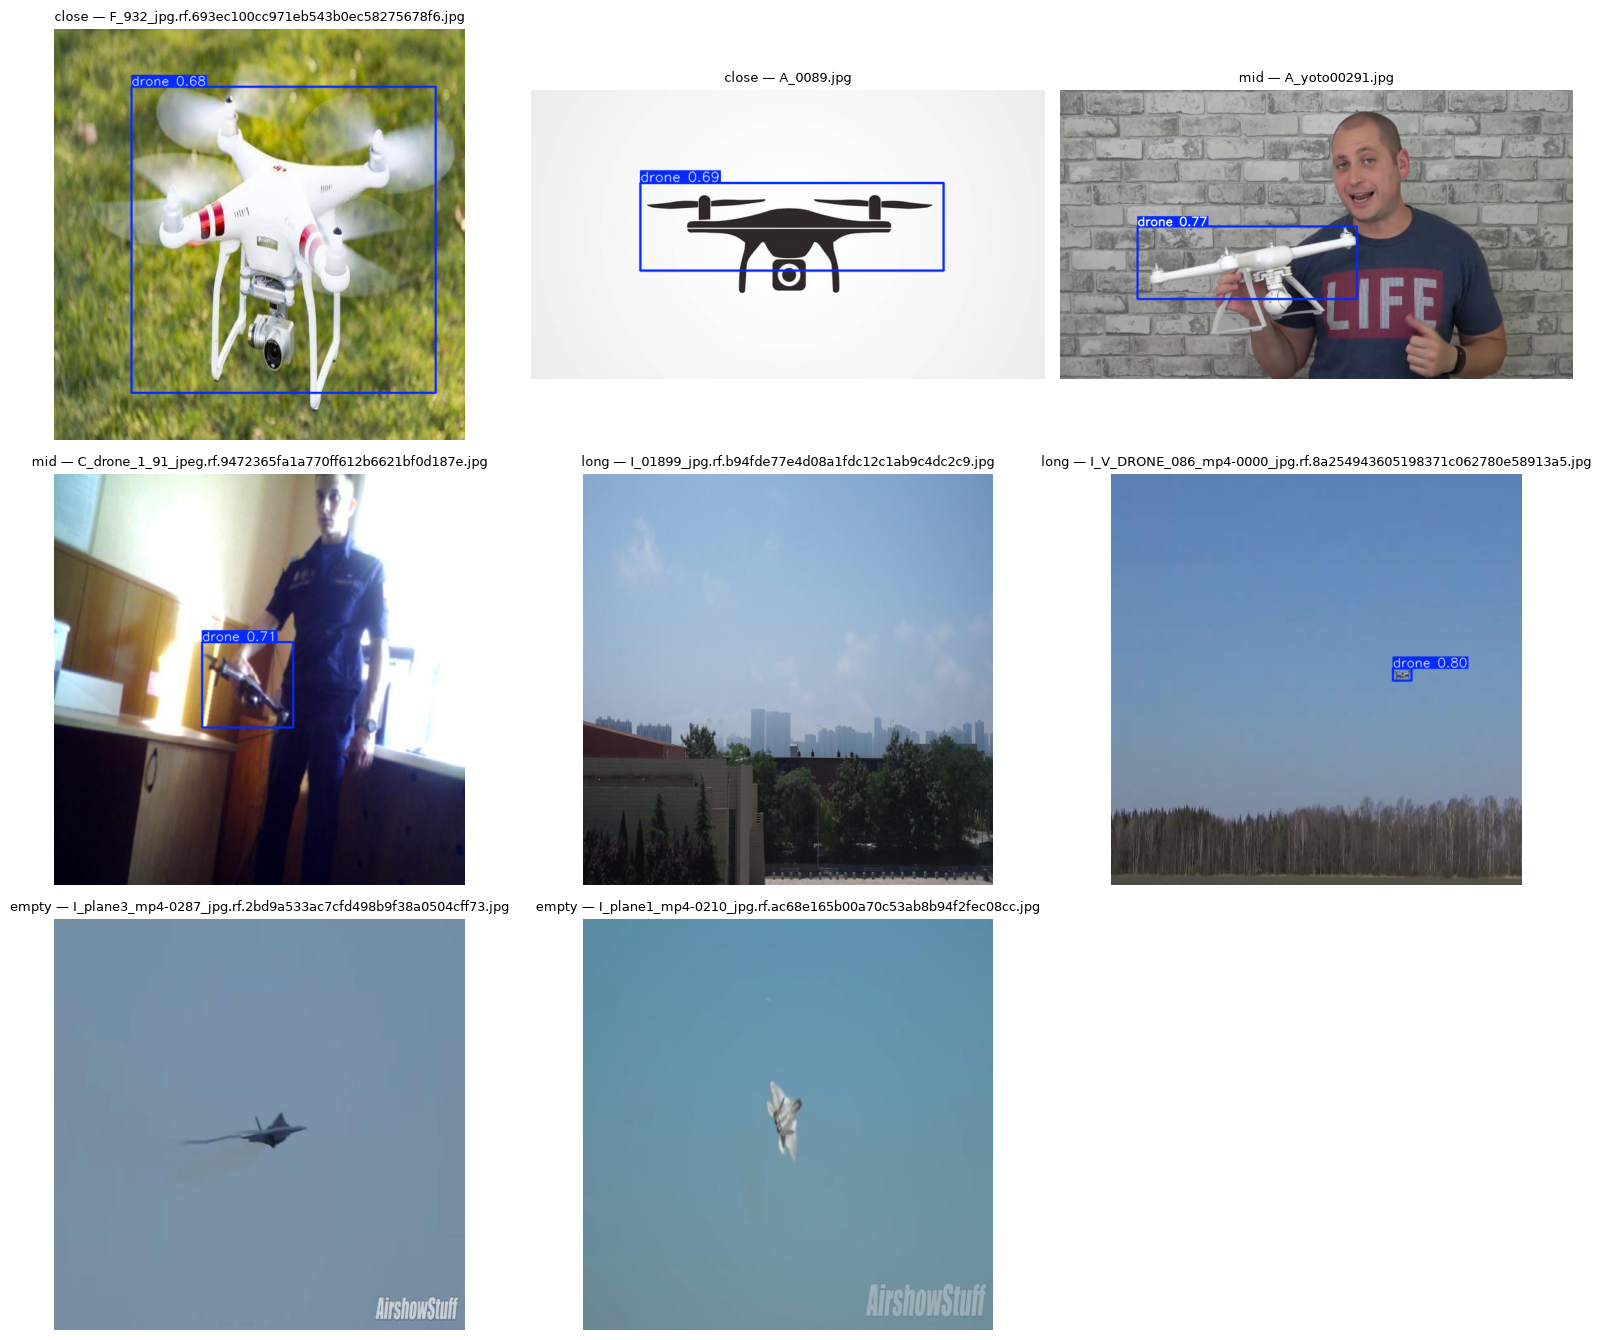

In [ ]:
%matplotlib inline
import glob
import matplotlib.pyplot as plt

VIZ_CONF = 0.25       # lower than CONF_THR so marginal detections stay visible

# Sample by REGIME from the manifest, not by source prefix
man = pd.read_csv('data/drone/manifest.csv')
val_man = man[man.split == 'val']

PER_REGIME = 2
imgs, titles = [], []
for reg in ('close', 'mid', 'long', 'empty'):
    sub = val_man[val_man.regime == reg]
    if sub.empty:
        continue
    for stem in sub.sample(min(PER_REGIME, len(sub)), random_state=0).stem:
        hit = glob.glob(f'data/drone/val/images/{stem}.*')
        if hit:
            imgs.append(hit[0])
            titles.append(f'{reg} — {Path(hit[0]).name}')

results = eval_model.predict(imgs, imgsz=CFG['img'], conf=VIZ_CONF, iou=IOU_NMS,
                             device=CFG['device'], verbose=False,
                             project=str(PROJ / 'runs' / 'predict'), name=RUN_DIR.name,
                             exist_ok=True)
print('detections / image:', [len(r.boxes) for r in results])

ncol = 3
nrow = (len(imgs) + ncol - 1) // ncol
fig, ax = plt.subplots(nrow, ncol, figsize=(16, 4.5 * nrow), squeeze=False)

for a, r, t in zip(ax.flat, results, titles):
    a.imshow(r.plot()[..., ::-1])     # Results.plot() draws boxes and returns BGR
    a.axis('off')
    a.set_title(t, fontsize=9)

for a in list(ax.flat)[len(imgs):]:
    a.axis('off')
plt.tight_layout()